# Real World Classification

## Task 0: Load data

Import the necessary libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np

seed=42
np.random.seed(seed)

load the data

In [3]:
# Load data from NYCU_Iris.csv
import pandas as pd
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,Species
0,1,7.0,3.2,4.7,1.4,16.9,37.5,Iris-versicolor
1,2,6.4,3.2,4.5,1.5,16.4,95.1,Iris-versicolor
2,3,6.9,3.1,4.9,1.5,16.9,73.2,Iris-versicolor
3,4,5.5,2.3,0.7,1.3,15.6,59.9,Iris-versicolor
4,5,6.5,2.8,4.6,1.5,16.4,15.6,Iris-versicolor


## Task 1: Preprocessing

In [4]:
from sklearn.preprocessing import LabelEncoder
feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm','BranchLength']

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col])
    
    # TODO: Drop the missing values, outliers and normalize the data to [0,1]
    # ---------- Start your code below ----------


    # ---------- --------------------- ----------
        
    return df

df = data_preprocessing(df)

## Task 2: Data Statistics

In [5]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,Species
count,500.000000,476.000000,493.000000,481.000000,478.000000,476.000000,500.000000,500.0000
mean,250.500000,6.320588,2.846856,4.995426,1.675732,16.302941,46.745800,0.5200
std,144.481833,1.033296,0.386004,1.823098,0.706689,1.035228,30.032428,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,0.0000
25%,125.750000,5.800000,2.600000,4.200000,1.300000,15.800000,18.500000,0.0000
50%,250.500000,6.300000,2.900000,4.900000,1.600000,16.300000,44.000000,1.0000
75%,375.250000,6.700000,3.100000,5.600000,2.000000,16.800000,73.200000,1.0000
max,500.000000,9.600000,4.000000,9.300000,4.300000,19.700000,98.700000,1.0000


## Task 3: Model Training

### Prepare the data

In [6]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,Species
0,1,7.0,3.2,4.7,1.4,16.9,37.5,0
1,2,6.4,3.2,4.5,1.5,16.4,95.1,0
2,3,6.9,3.1,4.9,1.5,16.9,73.2,0
3,4,5.5,2.3,0.7,1.3,15.6,59.9,0
4,5,6.5,2.8,4.6,1.5,16.4,15.6,0


### Train the model!

20. Training loss: nan, Val loss:nan
40. Training loss: nan, Val loss:nan
60. Training loss: nan, Val loss:nan
80. Training loss: nan, Val loss:nan
100. Training loss: nan, Val loss:nan
120. Training loss: nan, Val loss:nan
140. Training loss: nan, Val loss:nan
160. Training loss: nan, Val loss:nan
180. Training loss: nan, Val loss:nan
200. Training loss: nan, Val loss:nan
220. Training loss: nan, Val loss:nan
240. Training loss: nan, Val loss:nan
260. Training loss: nan, Val loss:nan
280. Training loss: nan, Val loss:nan
300. Training loss: nan, Val loss:nan
320. Training loss: nan, Val loss:nan
340. Training loss: nan, Val loss:nan
360. Training loss: nan, Val loss:nan
380. Training loss: nan, Val loss:nan
400. Training loss: nan, Val loss:nan
420. Training loss: nan, Val loss:nan
440. Training loss: nan, Val loss:nan
460. Training loss: nan, Val loss:nan
480. Training loss: nan, Val loss:nan
500. Training loss: nan, Val loss:nan
520. Training loss: nan, Val loss:nan
540. Training lo

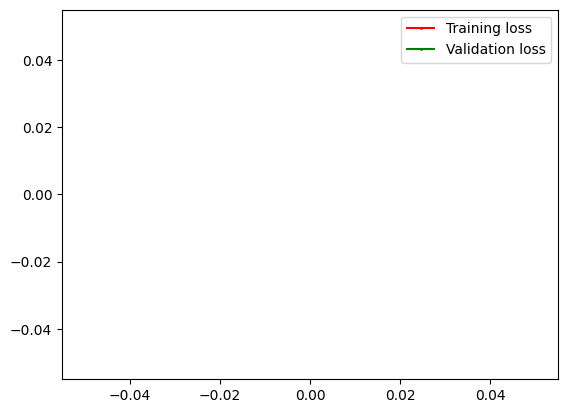

Model parameters (weights): [[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]
Sum of absolute values of weights: nan


In [7]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import accuracy,logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Task 4: Metrics

Model Evaluation
  Accuracy: 0.4733
 Precision: 0.0000
    Recall: 0.0000
  F1-score: 0.0000


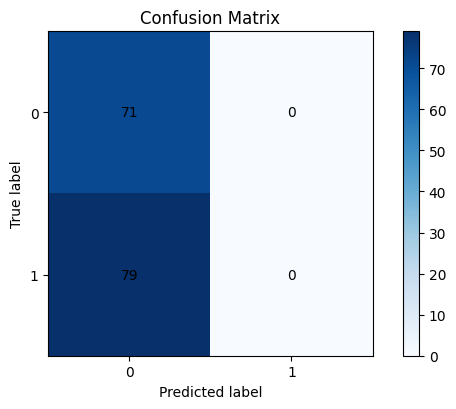

{'Accuracy': 0.47333333333333333,
 'Precision': 0.0,
 'Recall': 0.0,
 'F1-score': 0.0}

In [ ]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

## Task 5: K-fold Cross-Validation

In [9]:
#TODO: Implement the K-fold cross validation